In [1]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, HTML
import warnings
warnings.filterwarnings('ignore')


# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

# KerasNLP pour BERT
import keras_nlp

# Sklearn pour métriques
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

OPTIMIZE = False
if OPTIMIZE:
    from scikeras.wrappers import KerasClassifier

# Keggle hub pour dataset
import kagglehub

import re
import os


# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"\n📦 TensorFlow version: {tf.__version__}")
print(f"📦 Keras version: {keras.__version__}")
print(f"📦 KerasNLP version: {keras_nlp.__version__}")

⚠️  Aucun GPU détecté - Utilisation du CPU

📦 TensorFlow version: 2.20.0
📦 Keras version: 3.13.2
📦 KerasNLP version: 0.26.0


## 2. Récupération des données



In [2]:
print("Récupération des données...")
# Récupérer les données
path = kagglehub.dataset_download("haideradnan77/mental-health-condition-classification")

for f in os.listdir(path):
    df = pd.read_csv(os.path.join(path, f))

print(".. OK")

print("Nombre d'entrées : ", df.shape[0])

df.head()



Récupération des données...
.. OK
Nombre d'entrées :  103488


,text,status
0,"""My mind is a never-ending cycle of worry, and...",anxiety
1,Despite the sun shining and birds singing outs...,bipolar
2,"I'm drowning in responsibilities, each one dem...",stress
3,"""My emotions shift like the wind, leaving me u...",personality disorder
4,"I'm trapped in a whirlwind of thoughts, unable...",anxiety


## 4. Division des données

In [3]:
X_train_all, X_test_raw, y_train_all, y_test_raw = train_test_split(df["text"], df["status"], test_size=0.2, random_state=SEED)

# Créer un validation set
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_all, y_train_all, test_size=0.25, random_state=SEED, stratify=y_train_all
)

print(f"✅ Préparation terminée !")
print(f"\n📊 Répartition finale:")
print(f"   Train: {len(X_train_raw):,} elements")
print(f"   Validation: {len(X_val_raw):,} elements")
print(f"   Test: {len(X_test_raw):,} elements")


✅ Préparation terminée !

📊 Répartition finale:
   Train: 62,092 elements
   Validation: 20,698 elements
   Test: 20,698 elements


## 5. Nettoyage des données

In [4]:
# nettoyage et normalisation du texte
def clean_text(text: str):
    # Supprimer les sauts de ligne, remplacement de doubles quotes, convertir en minuscules
    text = text.replace("\n", " ").replace("\"", " ").lower()
    # Ajouter des espaces autour de la ponctuation
    text = re.sub(r"([.,!?'])", r" \1 ", text)
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

X_train = X_train_raw.transform(clean_text)
X_val = X_val_raw.transform(clean_text)
X_test = X_test_raw.transform(clean_text)

train_lengths = [len(elem.split(" ")) for elem in X_train]
print(f'Mean: {np.mean(train_lengths):.0f}, Std: {np.std(train_lengths):.0f}')

print("Nettoyage terminé")


Mean: 93, Std: 140
Nettoyage terminé


In [6]:
statuses = df.groupby("status")

CLASSES_COUNT = len(statuses)
print(f"Nous avons {CLASSES_COUNT} classes:")

for name, group in statuses:
    print("\t", name, len(group))


chart_values = [len(group) for _, group in statuses]
chart_labels = [name for name, _ in statuses]

Nous avons 7 classes:
	 anxiety 17620
	 bipolar 13708
	 depression 15901
	 normal 16068
	 personality disorder 13915
	 stress 15230
	 suicidal 11046


In [7]:
# Configuration
MAX_WORDS = 10000
MAX_LEN = 250

# tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')

tokenizer.fit_on_texts(X_train)
VOCAB_SIZE = len(tokenizer.word_index) + 1  # +1 pour le padding

print(f"\nVocabulaire: {VOCAB_SIZE} tokens")

# padding
tokenized_X_train = tokenizer.texts_to_sequences(X_train)
tokenized_X_val = tokenizer.texts_to_sequences(X_val)
tokenized_X_test = tokenizer.texts_to_sequences(X_test)

# padding
pad_X_train = pad_sequences(tokenized_X_train, maxlen=MAX_LEN, padding='post')
pad_X_val = pad_sequences(tokenized_X_val, maxlen=MAX_LEN, padding='post')
pad_X_test = pad_sequences(tokenized_X_test, maxlen=MAX_LEN, padding='post')

max_sequence_length = max([len(phrase) for phrase in tokenized_X_train])

# labels
y_labels = chart_labels

y_train_array = y_train_raw.transform(lambda x: y_labels.index(x))
y_train = tf.keras.utils.to_categorical(y_train_array, num_classes=len(y_labels))

y_val_array = y_val_raw.transform(lambda x: y_labels.index(x))
y_val = tf.keras.utils.to_categorical(y_val_array, num_classes=len(y_labels))

y_test_array = y_test_raw.transform(lambda x: y_labels.index(x))
y_test = tf.keras.utils.to_categorical(y_test_array, num_classes=len(y_labels))

print(f"\n Dimensions des données :")
print(f"  X (input)  : {pad_X_train.shape} - (nombre_sequences, longueur_sequence)")
print(f"  y (output) : {y_train.shape} - (nombre_sequences, classes)")
print(f"\n  Longueur maximale de séquence : {max_sequence_length}")



Vocabulaire: 49948 tokens

 Dimensions des données :
  X (input)  : (62092, 250) - (nombre_sequences, longueur_sequence)
  y (output) : (62092, 7) - (nombre_sequences, classes)

  Longueur maximale de séquence : 5262


In [8]:
class LivePlotCallback(Callback):
    """
    Callback pour visualiser les métriques d'entraînement en temps réel.
    """
    def on_train_begin(self, logs=None):
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.accuracy = []
        self.val_accuracy = []
        
    def on_epoch_end(self, epoch, logs=None):
        # Enregistrement des métriques
        self.epochs.append(epoch + 1)
        self.loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.accuracy.append(logs.get('accuracy'))
        self.val_accuracy.append(logs.get('val_accuracy'))
        
        # Effacement et redessin
        clear_output(wait=True)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Graphique de la loss
        ax1.plot(self.epochs, self.loss, 'o-', label='Loss d\'entraînement',
                linewidth=2.5, markersize=8, color='#E63946')
        ax1.plot(self.epochs, self.val_loss, 's-', label='Loss de validation',
                linewidth=2.5, markersize=8, color='#F77F00')
        ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12, fontweight='bold')
        ax1.set_title('Évolution de la Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11, loc='upper right')
        ax1.grid(alpha=0.3)
        
        # Graphique de l'accuracy
        ax2.plot(self.epochs, self.accuracy, 'o-', label='Accuracy d\'entraînement',
                linewidth=2.5, markersize=8, color='#06AED5')
        ax2.plot(self.epochs, self.val_accuracy, 's-', label='Accuracy de validation',
                linewidth=2.5, markersize=8, color='#073B4C')
        ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax2.set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11, loc='lower right')
        ax2.grid(alpha=0.3)
        ax2.set_ylim([0, 1])
        
        plt.tight_layout()
        plt.show()
        
        # Affichage textuel
        print(f"\n{'='*70}")
        print(f"Epoch {epoch + 1}/{self.params['epochs']}")
        print(f"{'='*70}")
        print(f"Loss d'entraînement : {logs.get('loss'):.4f}")
        print(f"Accuracy d'entraînement : {logs.get('accuracy'):.4f} ({logs.get('accuracy')*100:.2f}%)")
        print(f"\nLoss de validation : {logs.get('val_loss'):.4f}")
        print(f"Accuracy de validation : {logs.get('val_accuracy'):.4f} ({logs.get('val_accuracy')*100:.2f}%)")
        print(f"{'='*70}")

print("✅ Callback de visualisation créé")

✅ Callback de visualisation créé


In [20]:
# creation du modèle
def create_model(dense_layers = 1, dense_units=64, dropout_rate=0.3, embedding_dim=128, kernel=7, learning_rate=0.01):
    model = models.Sequential()
    model.add(layers.Input(shape=(MAX_LEN,)))
    model.add(layers.Embedding(
            VOCAB_SIZE,
            embedding_dim,
            input_length=MAX_LEN,
            name='embedding'
        ),)
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Conv1D(embedding_dim, kernel, padding="valid", activation="relu", strides=3))
    model.add(layers.Conv1D(embedding_dim, kernel, padding="valid", activation="relu", strides=3))
    model.add(layers.GlobalMaxPooling1D())
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(CLASSES_COUNT, activation='softmax', name='output'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
     )

    return model

model = create_model()

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     6,393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 82, 128)        │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 26, 128)        │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,631,687 (25.30 MB)

 Trainable params: 6,631,687 (25.30 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
BATCH_SIZE = 64
EPOCHS = 30

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_on_plateau = ReduceLROnPlateau(patience=3)
live_plot = LivePlotCallback()

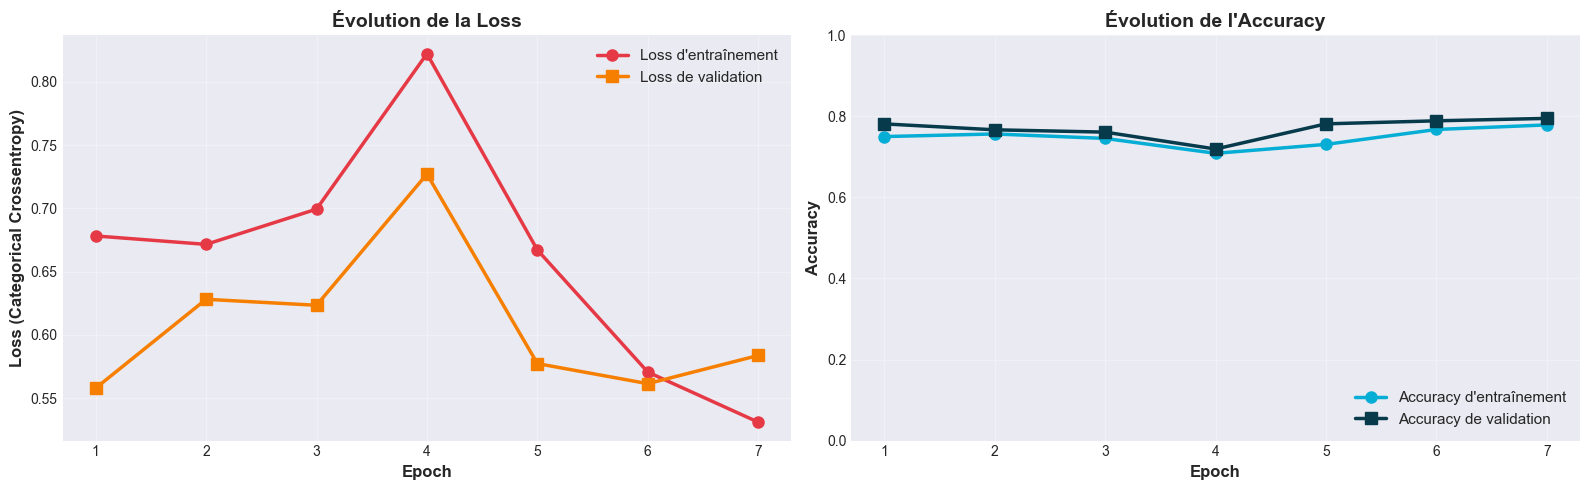


Epoch 7/30
Loss d'entraînement : 0.5309
Accuracy d'entraînement : 0.7790 (77.90%)

Loss de validation : 0.5837
Accuracy de validation : 0.7951 (79.51%)
971/971 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.7790 - loss: 0.5309 - val_accuracy: 0.7951 - val_loss: 0.5837 - learning_rate: 1.0000e-03

✅ Entraînement LSTM terminé !


In [22]:
print("Starting learning...")

history = model.fit(
    pad_X_train, y_train,
    validation_data=(pad_X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, live_plot, reduce_on_plateau],
)

print("\n✅ Entraînement LSTM terminé !")

In [23]:
# Évaluation
test_loss, test_acc = model.evaluate(pad_X_test, y_test, verbose=0)
print("\n📊 PERFORMANCES LSTM")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")



📊 PERFORMANCES LSTM
Test Loss: 0.5642
Test Accuracy: 0.7817 (78.17%)


In [24]:
phrases = [
    "I don't feel like getting up, everything seems so dull",
    "Something's gonna happen here, something bad and I cannot do anything to prevent it",
    "Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?",
    "I got up, went to work, it was a wonderful day",
    "I would like to go to sleep and never wake up anymore", 
    "Everything is going so fast, my head is spinning, my heart is racing, I need a break"
]

for phrase in phrases:
    clean_phrase = clean_text(phrase)
    tokenized_phrase = tokenizer.texts_to_sequences([clean_phrase])
    padded_phrase = pad_sequences(tokenized_phrase, maxlen=MAX_LEN, padding='post')
    pred = model.predict(padded_phrase)
    print(phrase)
    print("It is", y_labels[np.argmax(pred, axis=1)[0]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
I don't feel like getting up, everything seems so dull
It is normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Something's gonna happen here, something bad and I cannot do anything to prevent it
It is depression
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Yesterday I was full of energy and enthusiasm, now I am totally down, what's happening?
It is bipolar
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
I got up, went to work, it was a wonderful day
It is normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
I would like to go to sleep and never wake up anymore
It is normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Everything is going so fast, my head is spinning, my heart is racing, I need a break
It is anxiety


In [25]:
y_pred = model.predict(pad_X_test, verbose=0)

y_test_idx = np.argmax(y_test, axis=1)
y_pred_idx = np.argmax(y_pred, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_test_idx, y_pred_idx, target_names=y_labels))


📈 Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.91      0.89      0.90      3492
             bipolar       0.97      0.86      0.91      2764
          depression       0.42      0.43      0.43      3186
              normal       0.89      0.83      0.86      3223
personality disorder       0.99      0.93      0.96      2823
              stress       0.92      0.83      0.87      2963
            suicidal       0.49      0.69      0.57      2247

            accuracy                           0.78     20698
           macro avg       0.80      0.78      0.79     20698
        weighted avg       0.81      0.78      0.79     20698



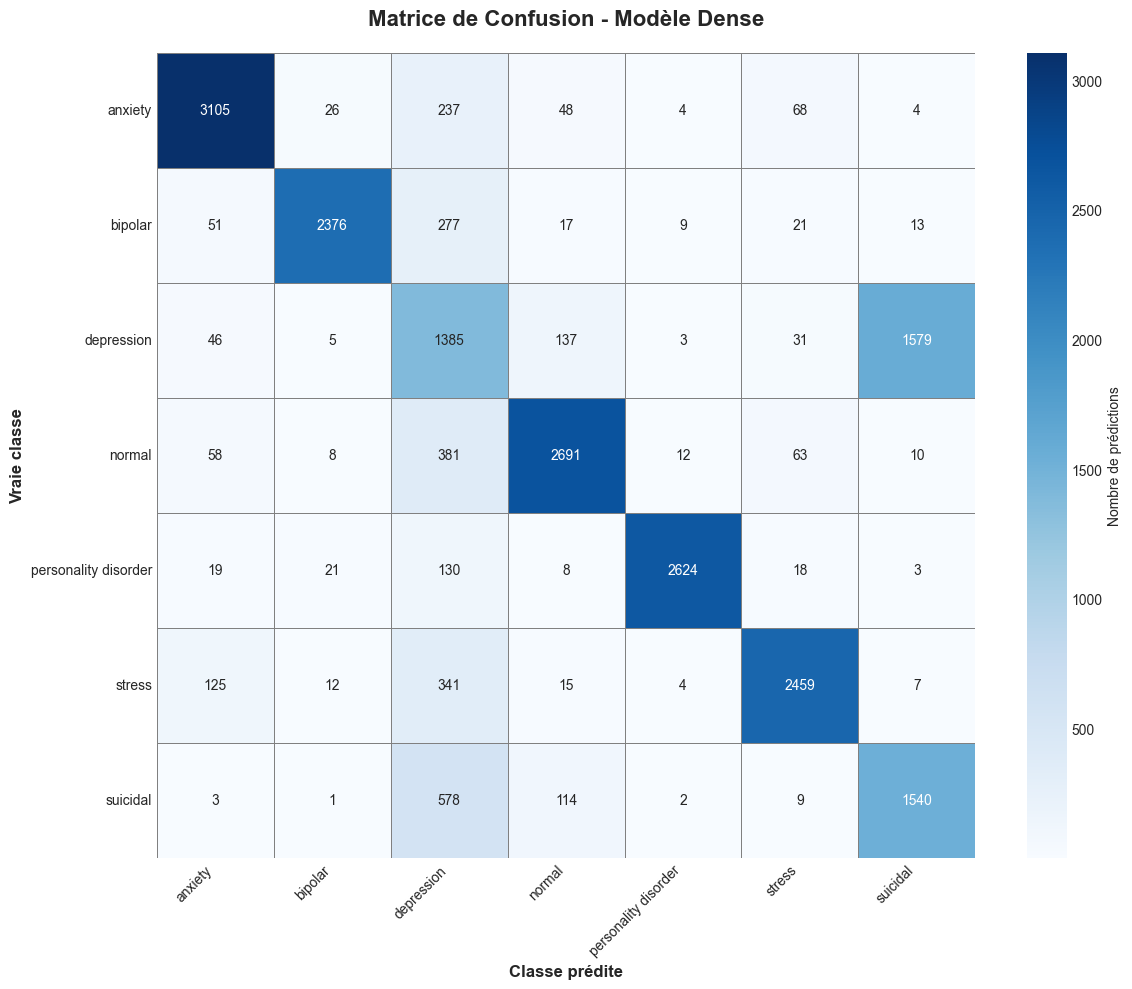

In [26]:
# Matrice de confusion
cm = confusion_matrix(y_test_idx, y_pred_idx)

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y_labels, yticklabels=y_labels,
            cbar_kws={'label': 'Nombre de prédictions'},
            linewidths=0.5, linecolor='gray')
plt.title('Matrice de Confusion - Modèle Dense', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Vraie classe', fontsize=12, fontweight='bold')
plt.xlabel('Classe prédite', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
BERT_MODEL_NAME="bert_small_en_uncased" #"bert_large_en_uncased" #"bert_medium_en_uncased", "distil_bert_base_en_uncased"

In [29]:
# Charger le préprocesseur BERT de KerasNLP
print("📥 Chargement du preprocesseur BERT...\n")

# Utiliser le preprocesseur BERT pré-entraîné
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    BERT_MODEL_NAME,
    sequence_length=128
)

print("✅ Preprocesseur chargé !")
print(f"\nVocabulaire: {preprocessor.tokenizer.vocabulary_size():,} tokens")
print(f"Longueur de séquence: 128")

📥 Chargement du preprocesseur BERT...

✅ Preprocesseur chargé !

Vocabulaire: 30,522 tokens
Longueur de séquence: 128


In [30]:
# Test du preprocesseur
test_text = "I don't feel like getting up, everything seems so dull"
preprocessed = preprocessor([test_text])

print(f"\n🔍 Test du preprocesseur:")
print(f"\nTexte original: '{test_text}'")
print(f"\nClés disponibles: {list(preprocessed.keys())}")
print(f"\ntoken_ids shape: {preprocessed['token_ids'].shape}")
print(f"segment_ids shape: {preprocessed['segment_ids'].shape}")
print(f"padding_mask shape: {preprocessed['padding_mask'].shape}")


🔍 Test du preprocesseur:

Texte original: 'I don't feel like getting up, everything seems so dull'

Clés disponibles: ['token_ids', 'padding_mask', 'segment_ids']

token_ids shape: (1, 128)
segment_ids shape: (1, 128)
padding_mask shape: (1, 128)


In [31]:
def create_frozen_bert_model(learning_rate=0.00003, dropout_rate=0.1, dense_units_count=64, dense_layers=1):
    """
    Crée un modèle BERT avec les poids gelés (Feature Extraction).
    """
    # Charger BERT pré-entraîné
    bert_backbone = keras_nlp.models.BertBackbone.from_preset(
        BERT_MODEL_NAME,  # Version légère
        trainable=False  # GELÉ
    )
    
    # Input
    inputs = {
        "token_ids": layers.Input(shape=(128,), dtype=tf.int32, name="token_ids"),
        "segment_ids": layers.Input(shape=(128,), dtype=tf.int32, name="segment_ids"),
        "padding_mask": layers.Input(shape=(128,), dtype=tf.int32, name="padding_mask"),
    }
    
    # BERT Encoder
    bert_output = bert_backbone(inputs)["sequence_output"]
    
    # Prendre le [CLS] token (première position)
    cls_token = bert_output[:, 0, :]
    
    # Couches de classification
    x = layers.Dropout(dropout_rate)(cls_token)
    for _ in range(0, dense_layers):
        x = layers.Dense(dense_units_count, activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(CLASSES_COUNT, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs, output)
    
    # Compiler
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, bert_backbone

# Créer le modèle
print("🔨 Création du modèle BERT (Feature Extraction)...\n")
bert_frozen_model, bert_backbone = create_frozen_bert_model()

print("✅ Modèle BERT (frozen) créé !\n")
bert_frozen_model.summary()

🔨 Création du modèle BERT (Feature Extraction)...

✅ Modèle BERT (frozen) créé !



Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 512),     │ 28,763,648 │ padding_mask[0][… │
│ (BertBackbone)      │ (None, 128, 512)] │            │ segment_ids[0][0… │
│                     │                   │            │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 512)       │          0 │ bert_backbone[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 512)       │          0 │ get_item_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     32,832 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        455 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,796,935 (109.85 MB)

 Trainable params: 33,287 (130.03 KB)

 Non-trainable params: 28,763,648 (109.72 MB)

In [32]:
# Préprocesser les données
print("🔄 Preprocessing des données avec BERT...\n")

X_train_bert = preprocessor(X_train_raw)
X_val_bert = preprocessor(X_val_raw)
X_test_bert = preprocessor(X_test_raw)

print("✅ Preprocessing terminé !")

🔄 Preprocessing des données avec BERT...

✅ Preprocessing terminé !


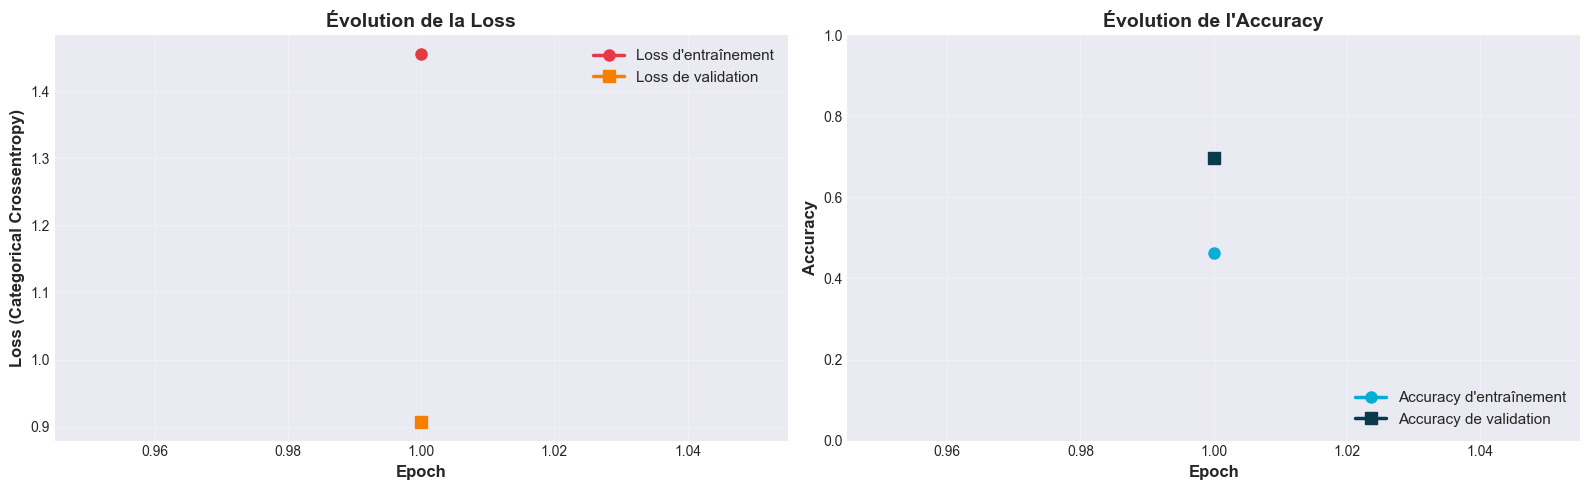


Epoch 1/100
Loss d'entraînement : 1.4559
Accuracy d'entraînement : 0.4633 (46.33%)

Loss de validation : 0.9066
Accuracy de validation : 0.6965 (69.65%)
971/971 ━━━━━━━━━━━━━━━━━━━━ 1628s 2s/step - accuracy: 0.4633 - loss: 1.4559 - val_accuracy: 0.6965 - val_loss: 0.9066
Epoch 2/100
496/971 ━━━━━━━━━━━━━━━━━━━━ 11:06 1s/step - accuracy: 0.6400 - loss: 1.0265

KeyboardInterrupt: 

In [33]:
# Entraînement
print("\n🚀 Entraînement BERT (Feature Extraction)...\n")

live_plot = LivePlotCallback()

history_bert_frozen = bert_frozen_model.fit(
    X_train_bert,
    y_train,
    validation_data=(X_val_bert, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[live_plot],
)

print("\n✅ Entraînement BERT (frozen) terminé !")